In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [3]:
# to download the data
od.download("https://www.kaggle.com/datasets/uciml/adult-census-income")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: hm
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/adult-census-income


100%|██████████| 450k/450k [00:00<00:00, 153MB/s]

In [4]:
data_income = pd.read_csv("/content/adult-census-income/adult.csv")


In [ ]:
data_income.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
data_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
data_income.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
for x in data_income:
  print(data_income[x].value_counts())

age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
fnlwgt
164190    13
203488    13
123011    13
148995    12
121124    12
          ..
136204     1
172274     1
70037      1
422013     1
216864     1
Name: count, Length: 21648, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [ ]:
data_income.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
data_income.drop_duplicates(inplace=True)

In [6]:
data_income["sex"] = data_income["sex"].map({"Male": 1,"Female": 0})
data_income["income"] = data_income["income"].map({"<=50K": 0,">50K": 1})
data_income.replace("?", np.nan, inplace=True)

In [7]:
data_income.dropna(inplace=True)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in data_income.columns:
  if data_income[col].dtype == "object":
     data_income[col] = le.fit_transform(data_income["education"])


In [ ]:
data_income.corr()["income"].sort_values(ascending=False)

,income
income,1.000000
education.num,0.335413
age,0.242017
hours.per.week,0.229435
capital.gain,0.221204
sex,0.216668
capital.loss,0.150026
workclass,0.079039
occupation,0.079039
education,0.079039


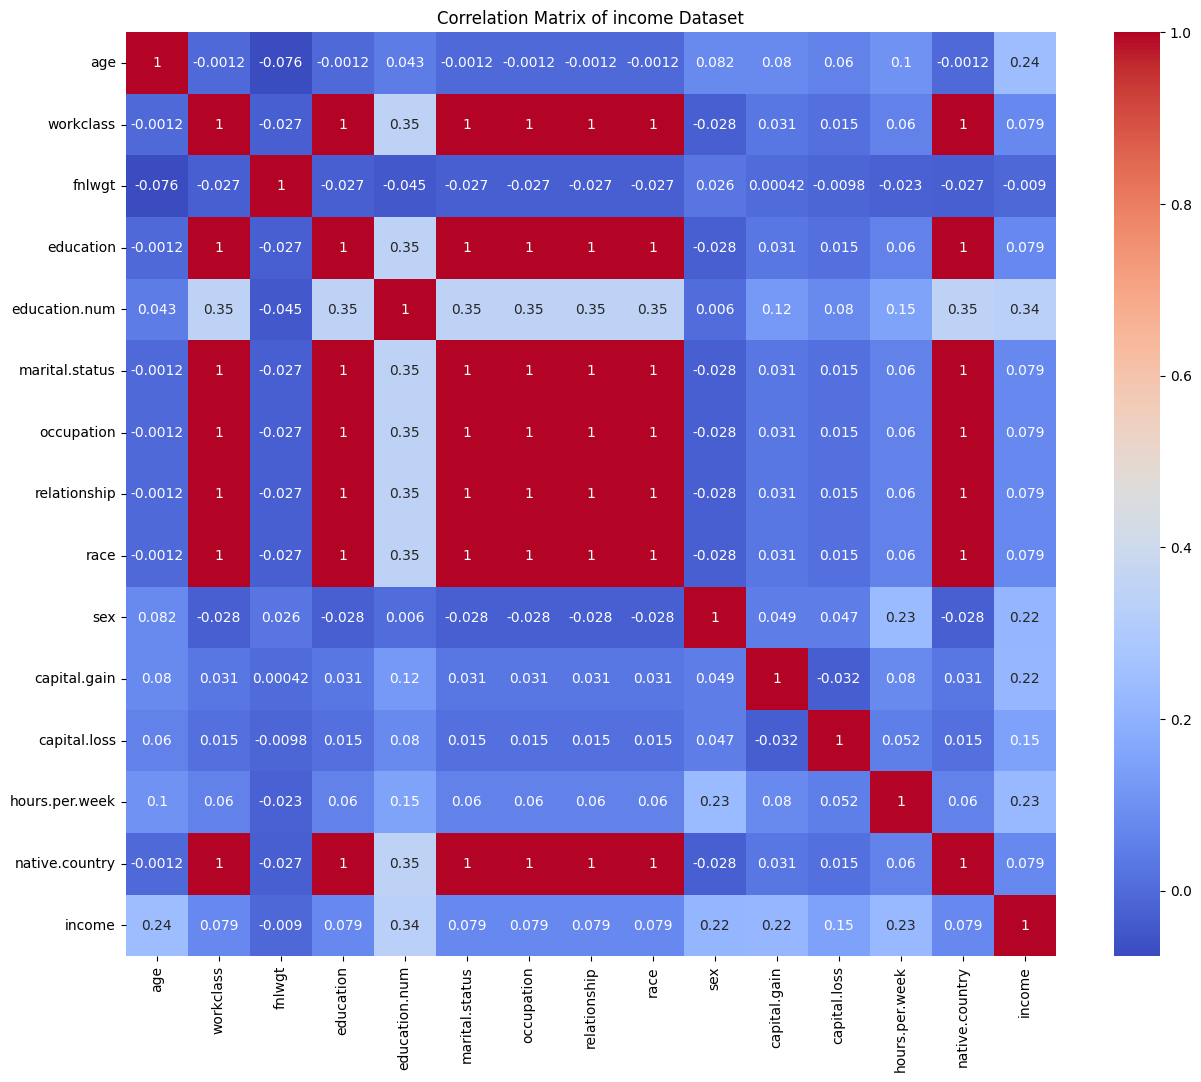

In [ ]:
plt.figure(figsize=(15, 12))
corr = data_income.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of income Dataset')
plt.show()

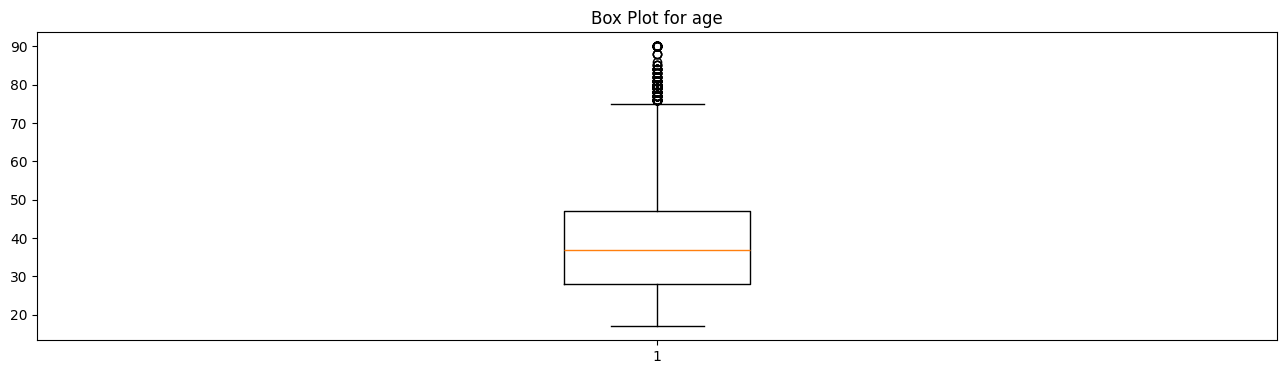

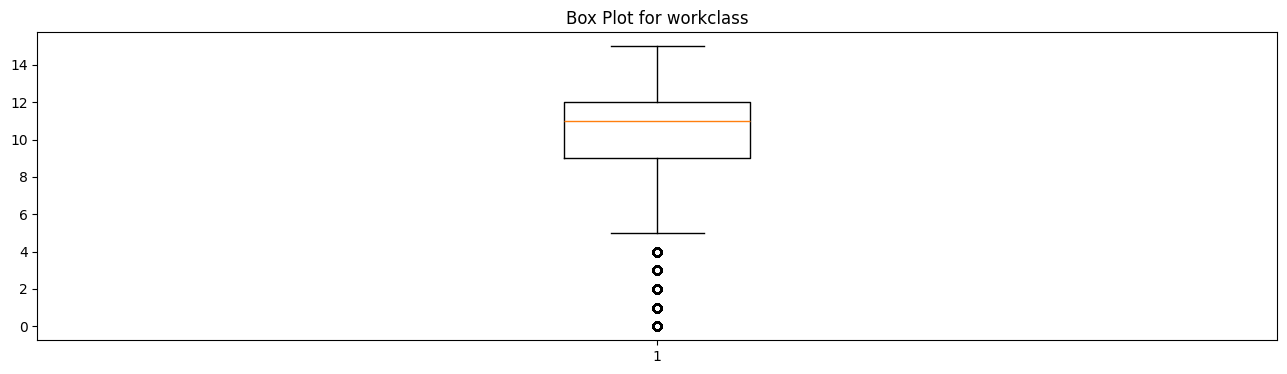

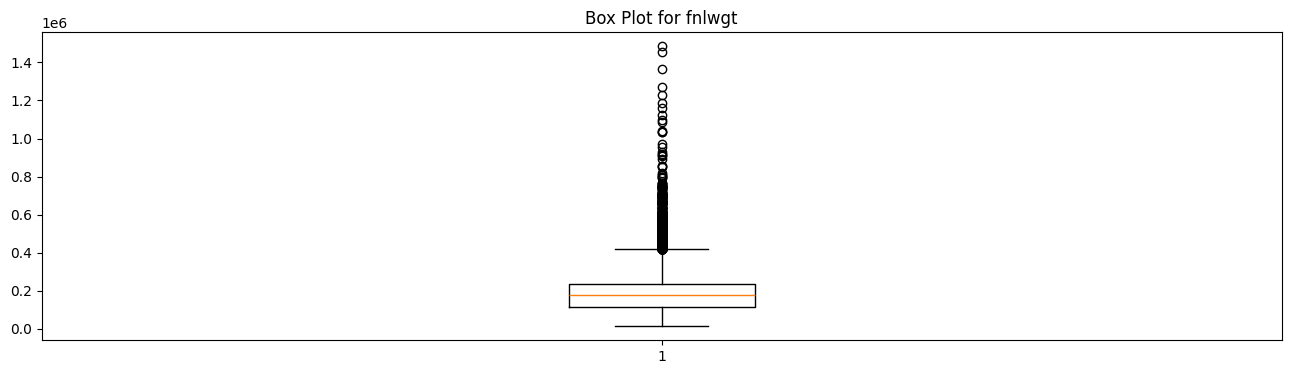

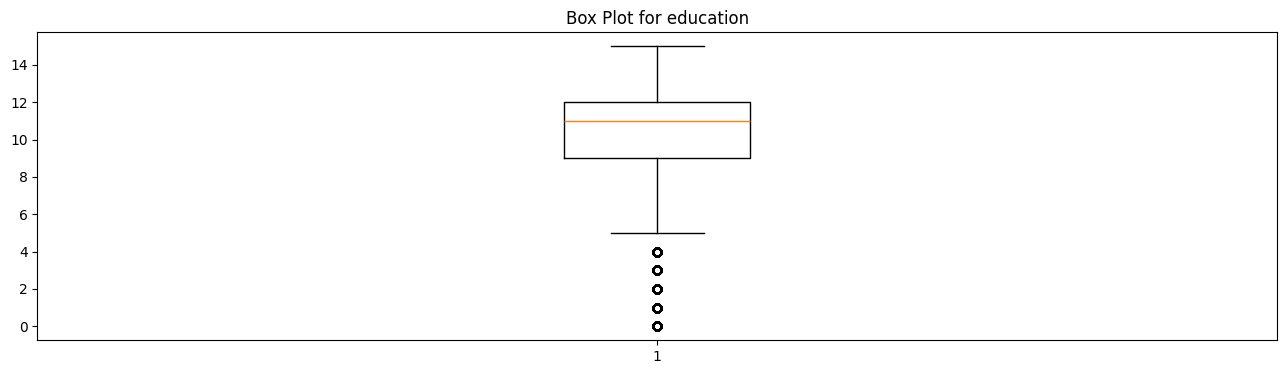

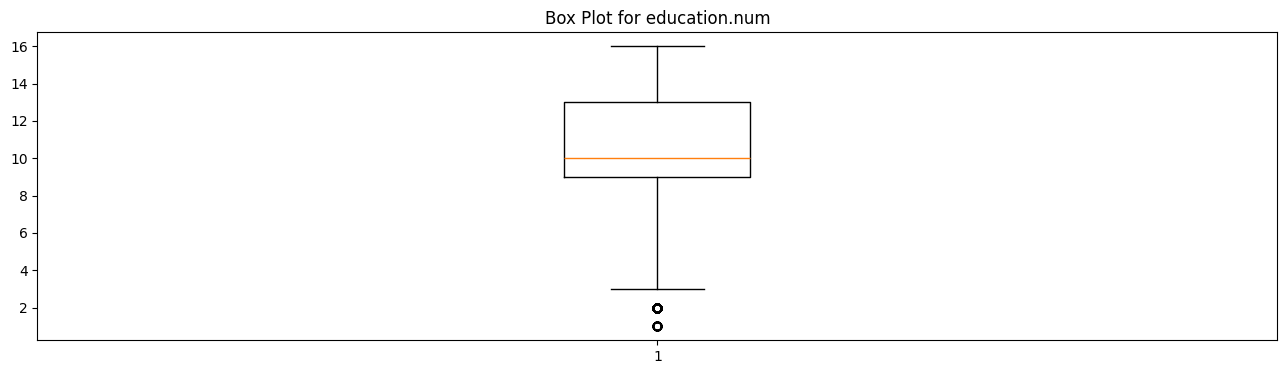

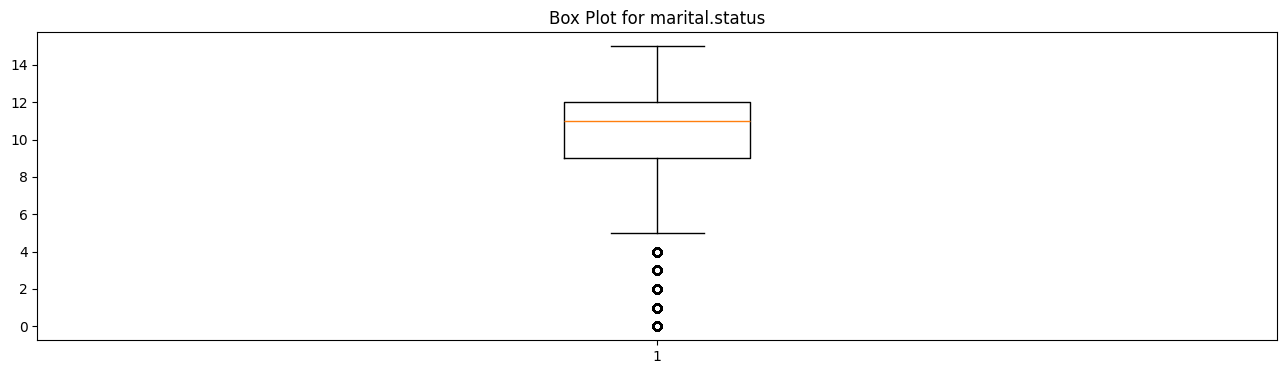

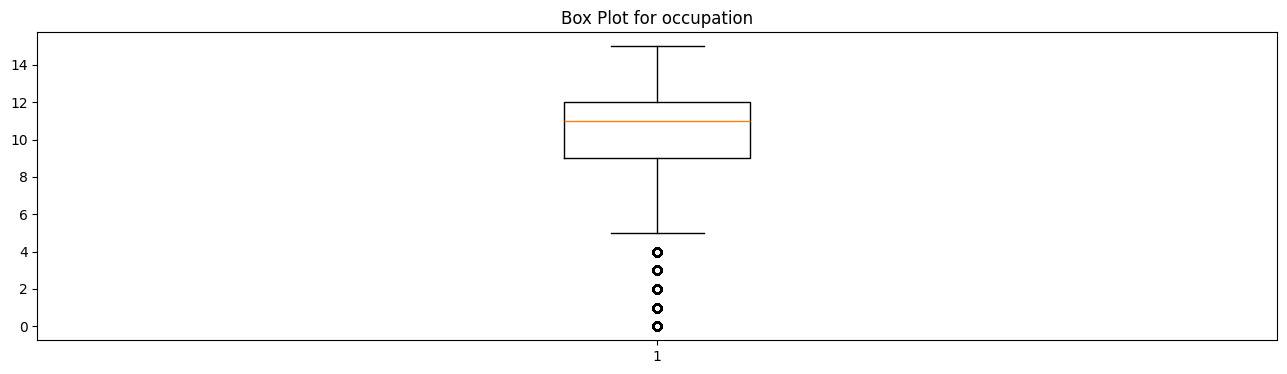

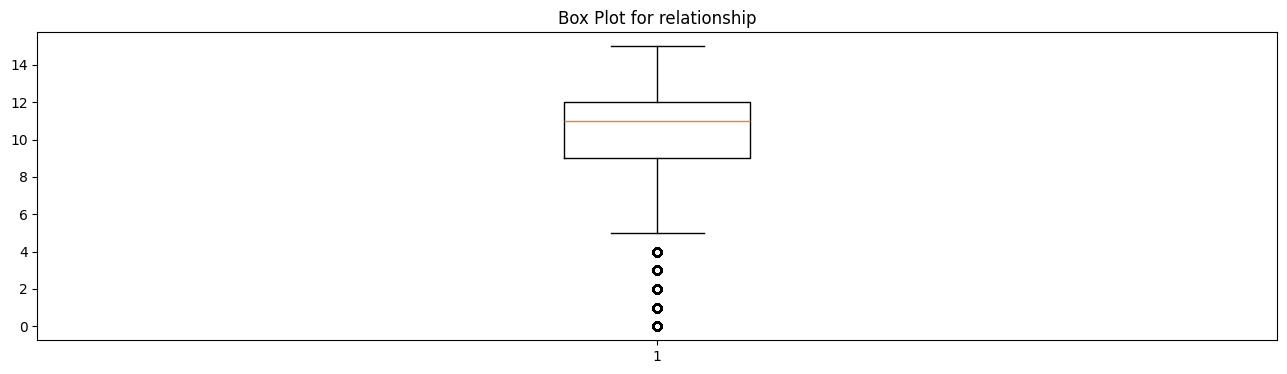

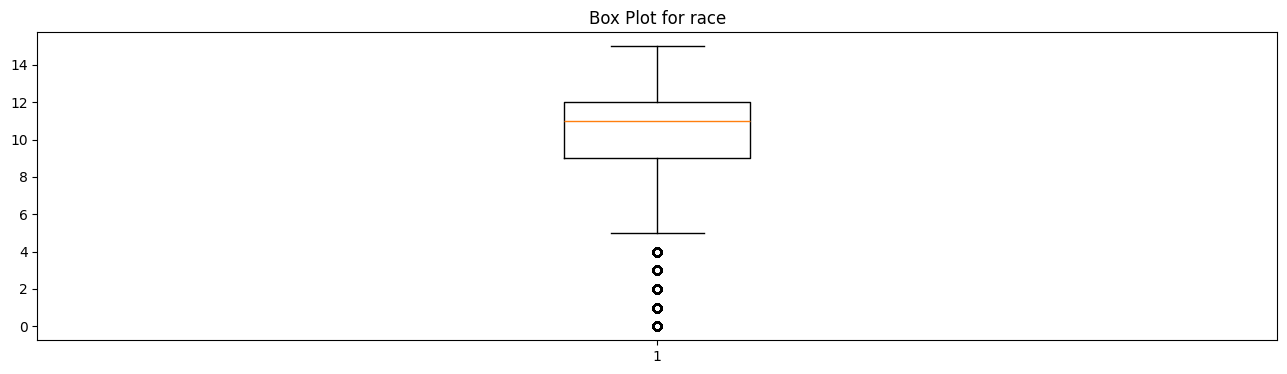

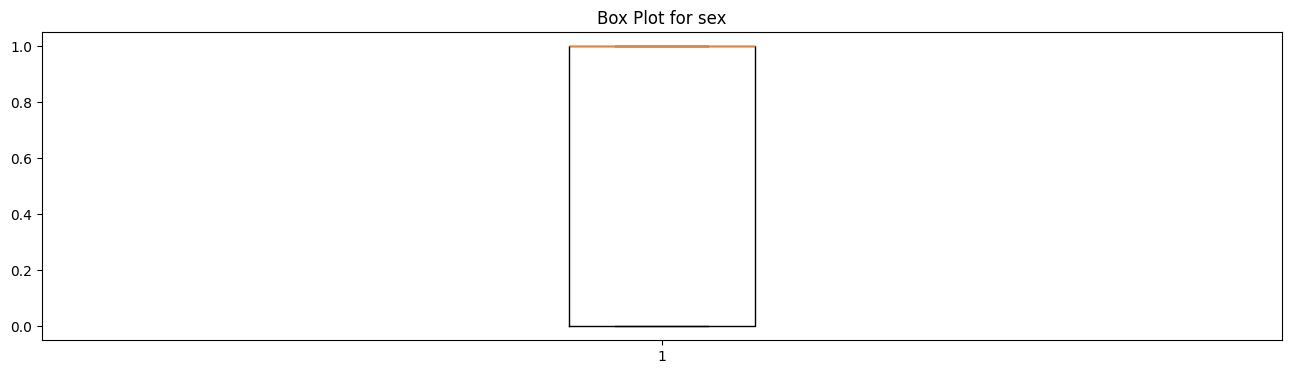

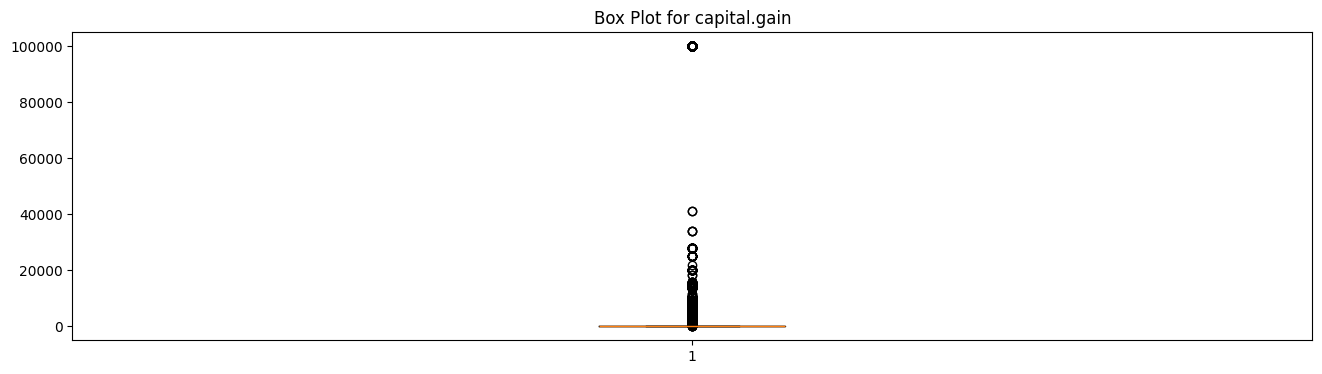

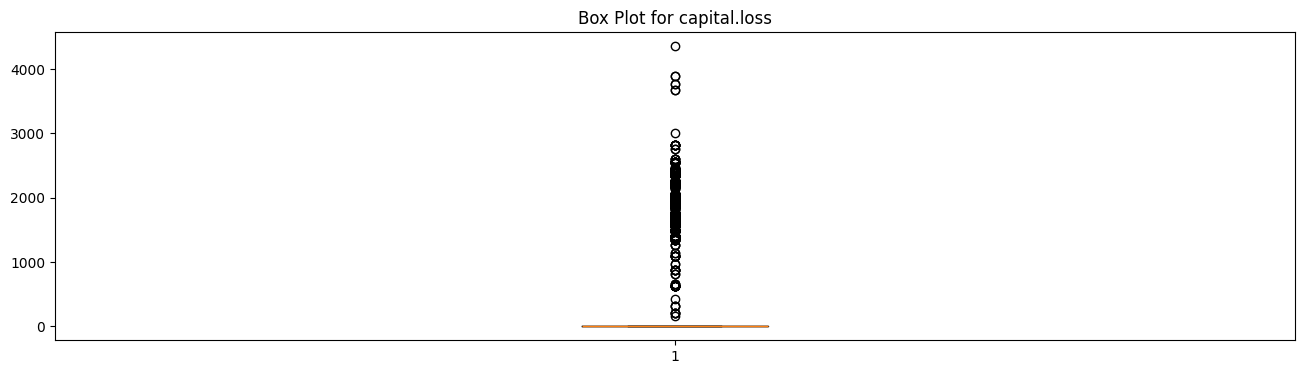

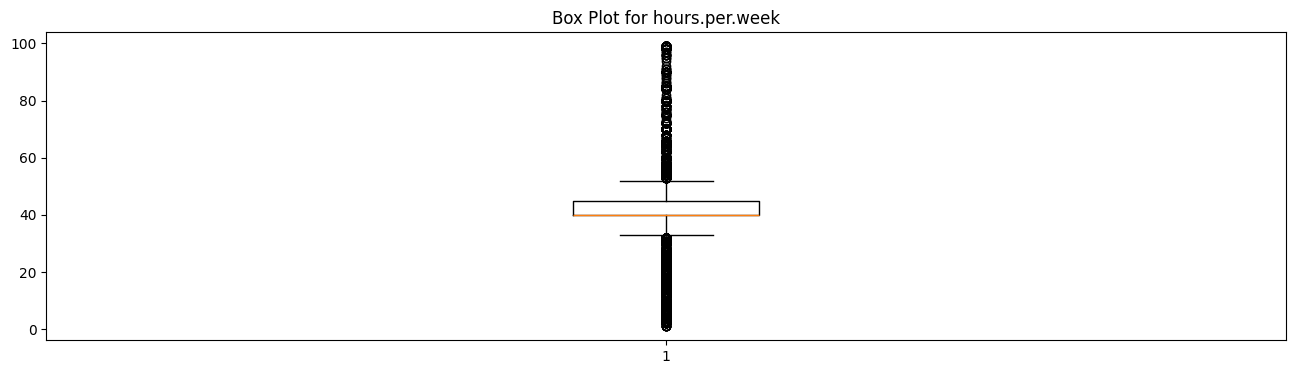

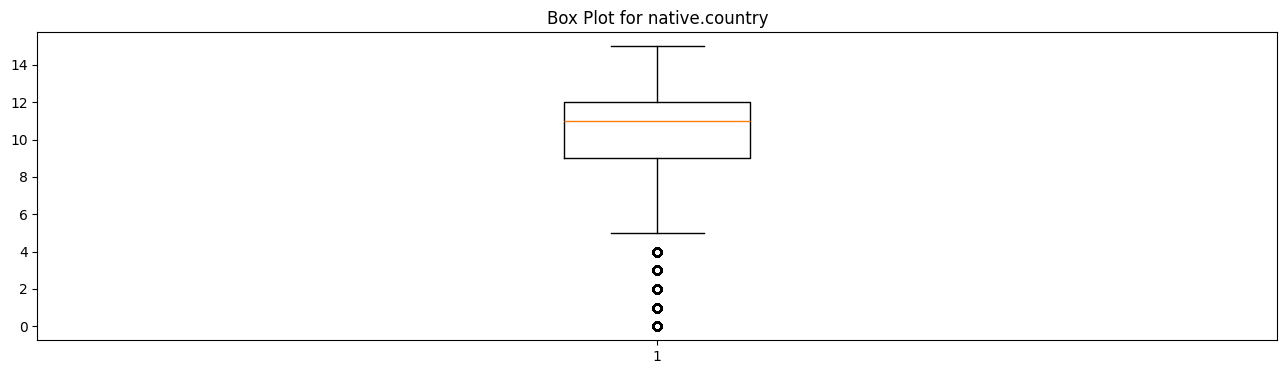

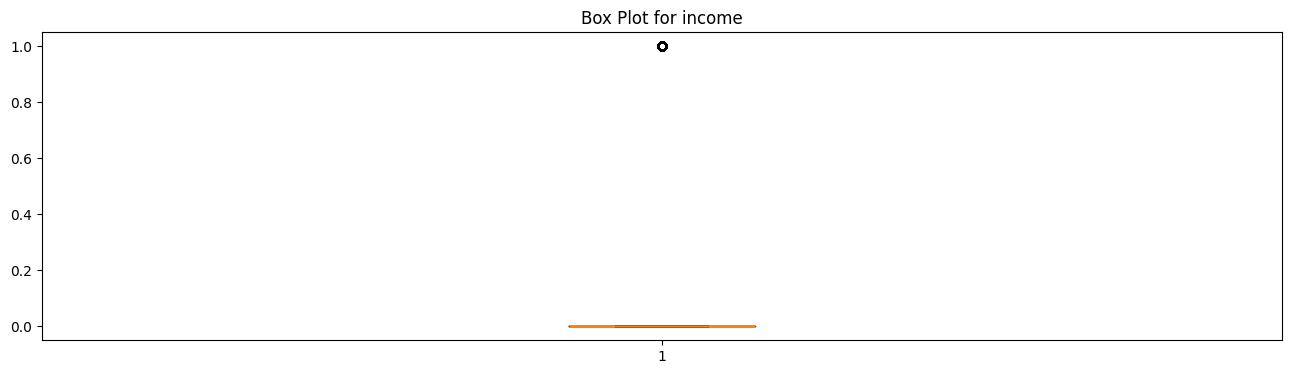

In [ ]:
for col in data_income :
 plt.figure(figsize=(16,4))
 plt.boxplot(data_income[col])
 plt.title(f"Box Plot for {col}")
 plt.show()

In [9]:
for col in data_income:
    Q1 = data_income[col].quantile(0.25)
    Q3 = data_income[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data_income = data_income[(data_income[col] >= lower_bound) |(data_income[col] <= upper_bound)]

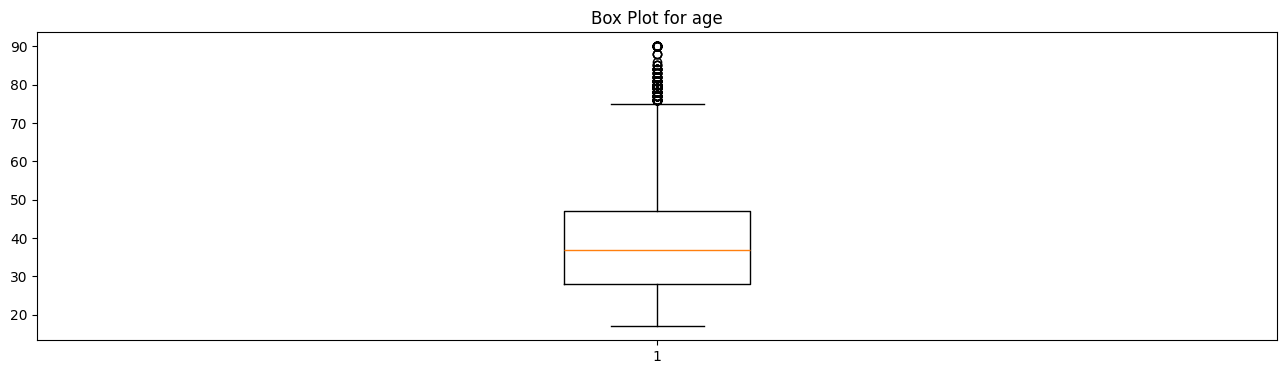

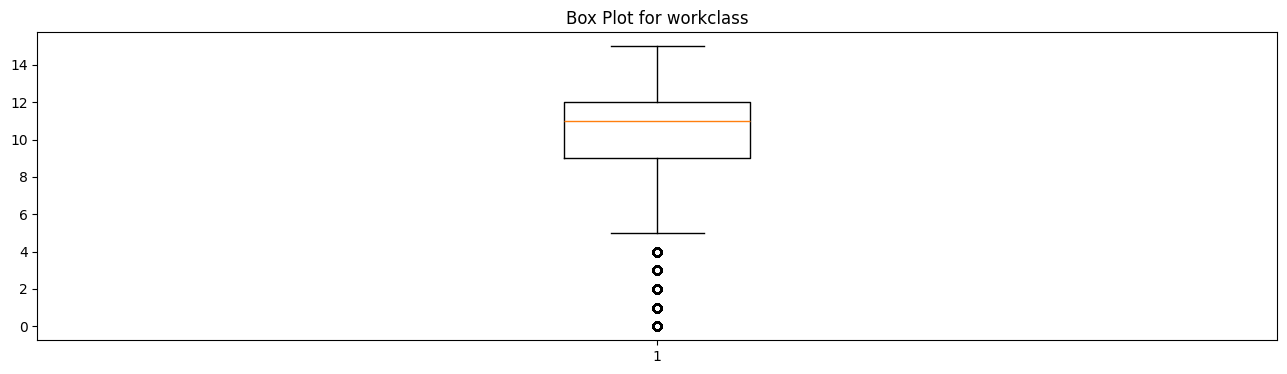

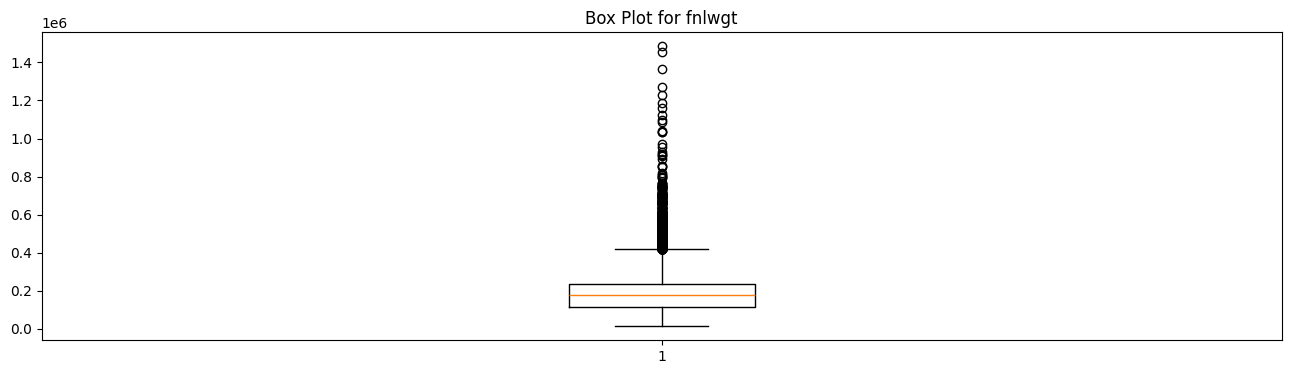

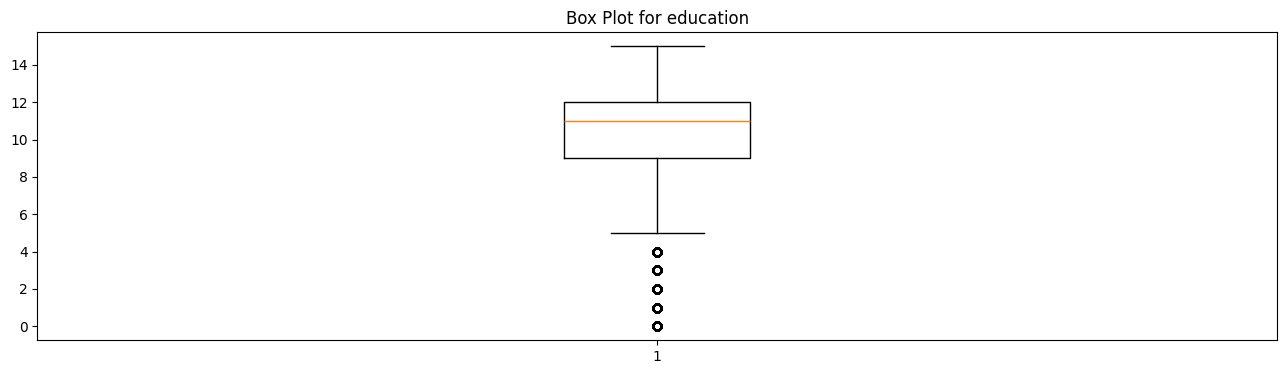

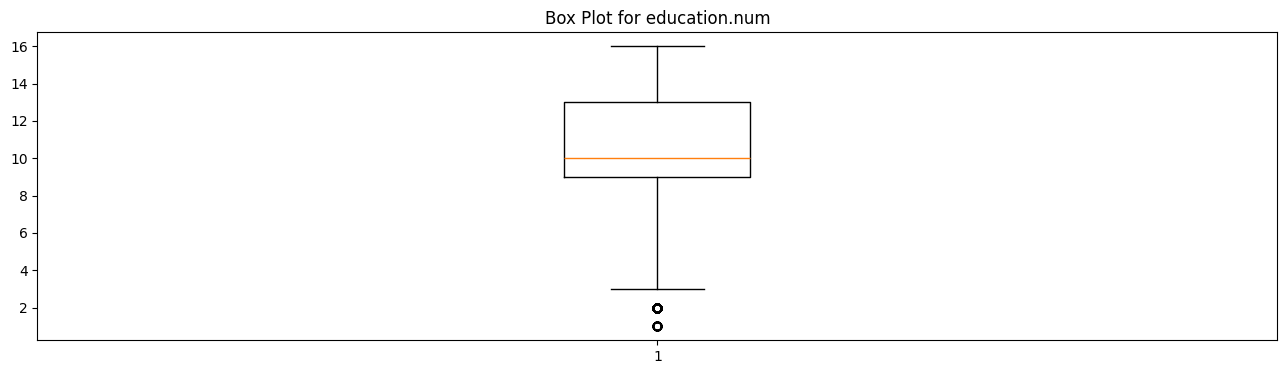

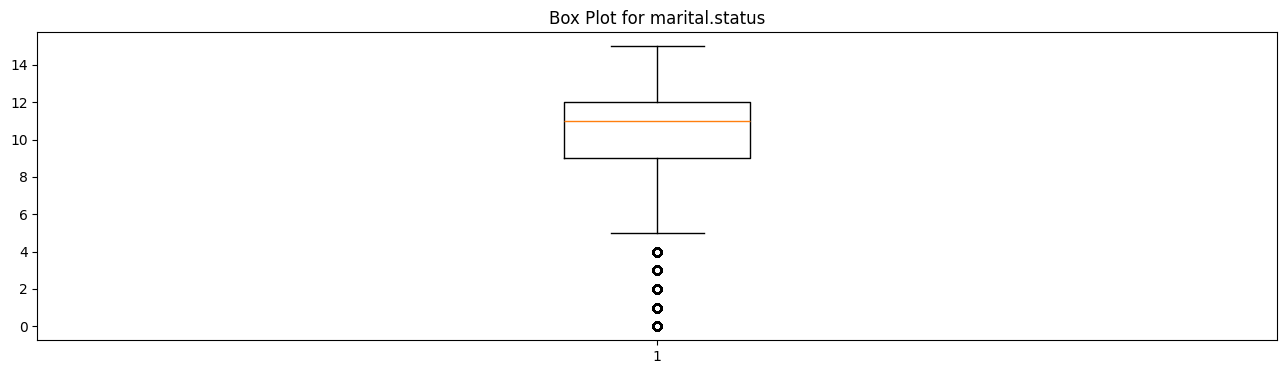

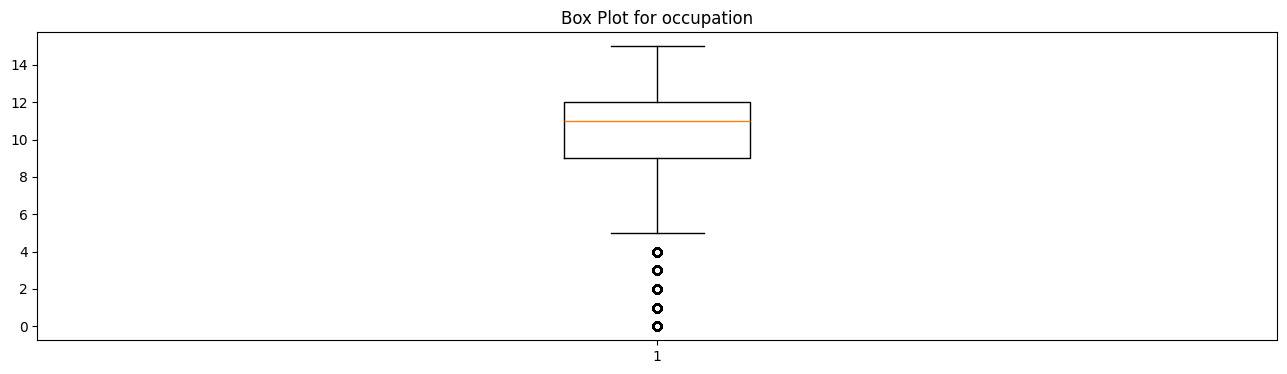

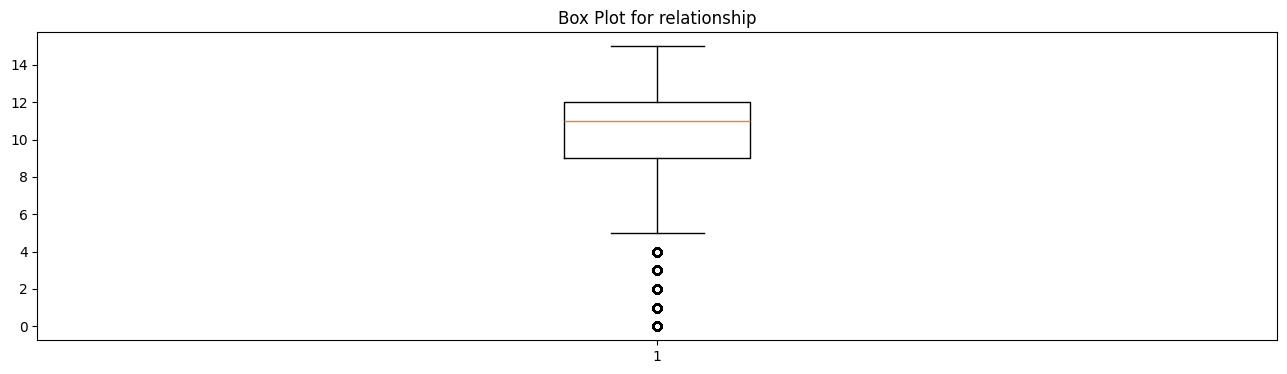

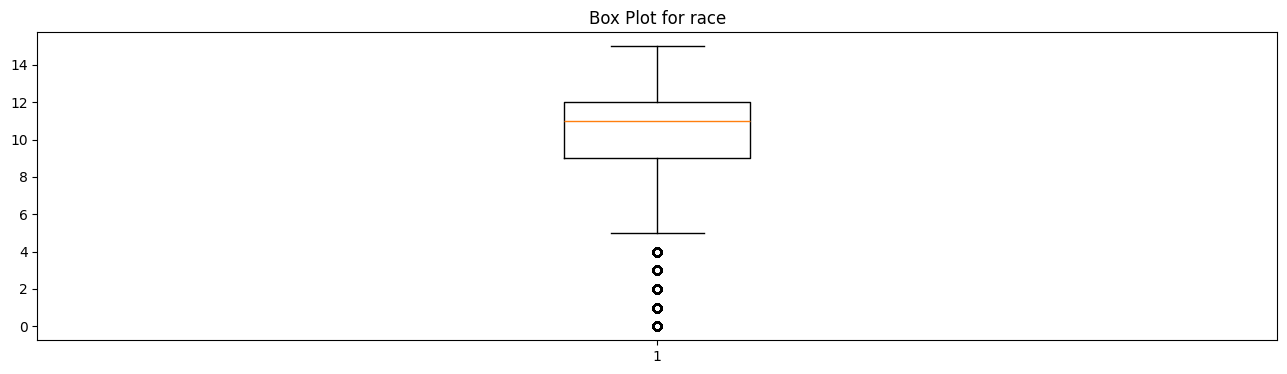

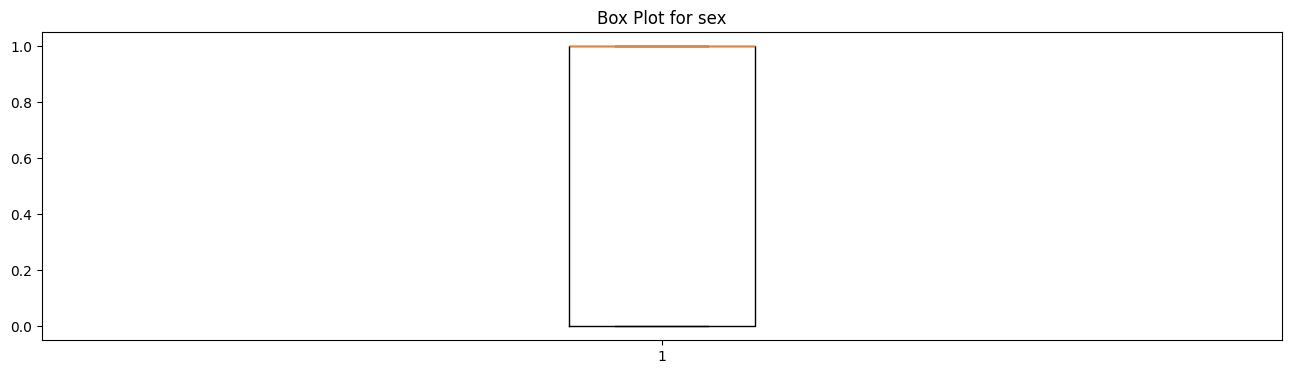

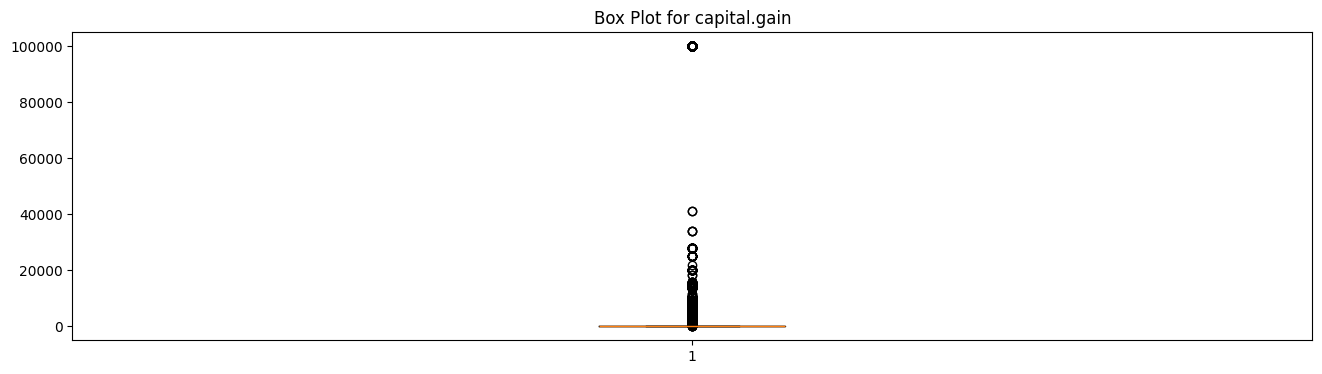

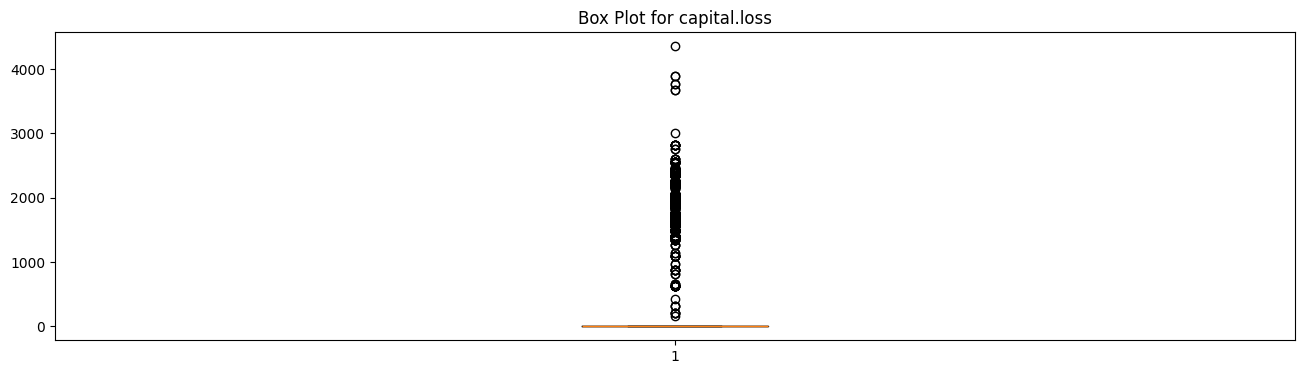

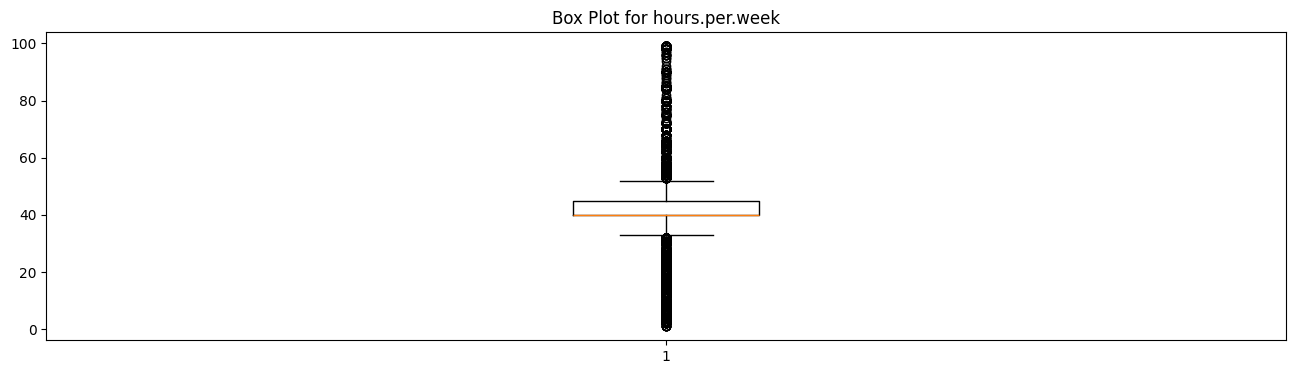

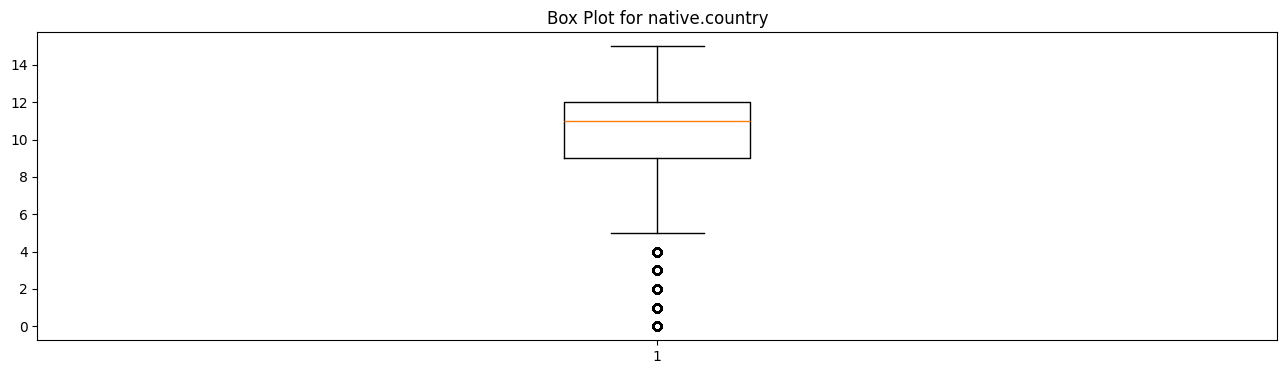

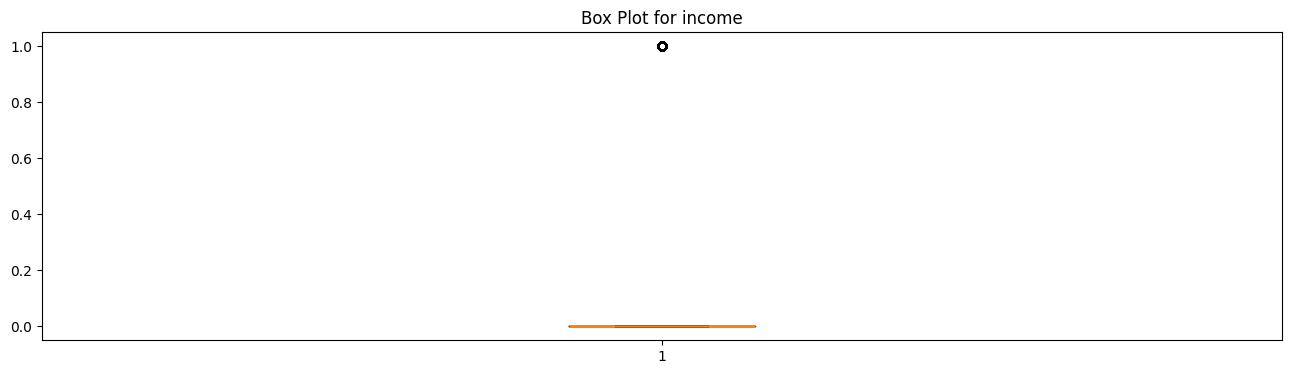

In [ ]:
for col in data_income :
 plt.figure(figsize=(16,4))
 plt.boxplot(data_income[col])
 plt.title(f"Box Plot for {col}")
 plt.show()

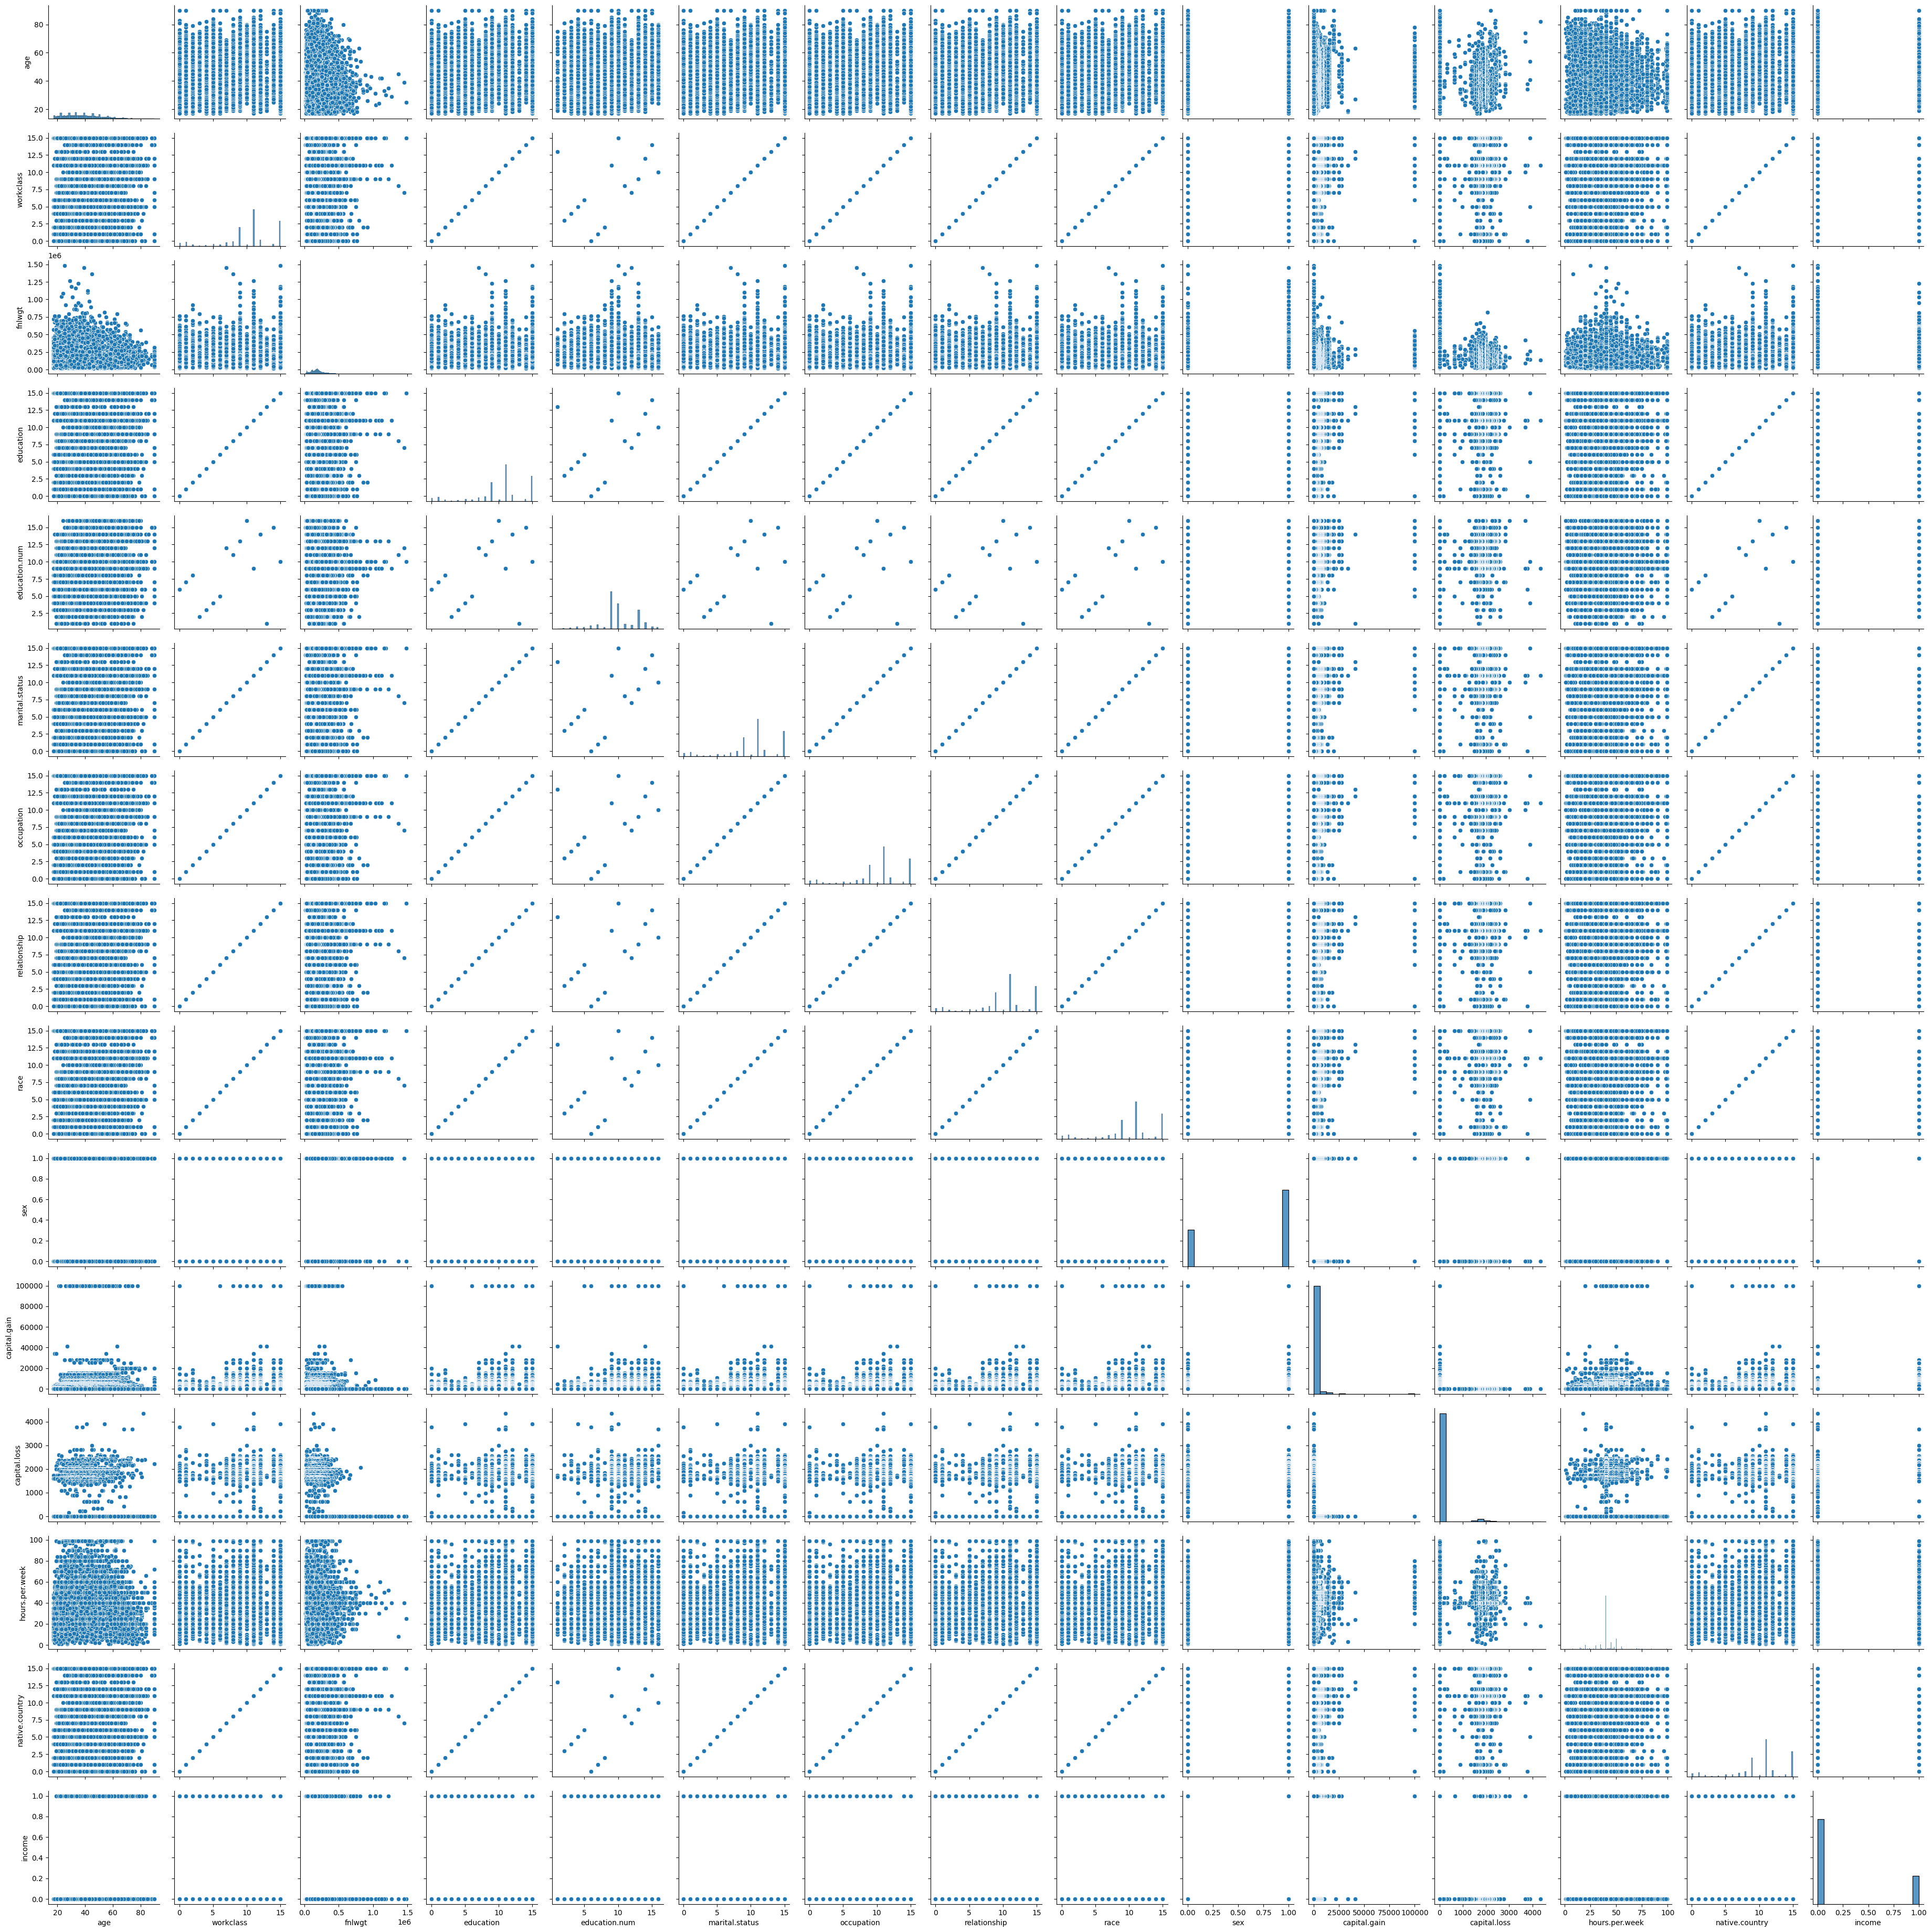

In [ ]:

sns.pairplot(data_income)
plt.show()

In [11]:
x = data_income.drop("income", axis=1)
y = data_income["income"]

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.3,random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print( accuracy_score(y_test, y_pred))
print( classification_report(y_test, y_pred))

0.822937403229374
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      6820
           1       0.72      0.46      0.56      2222

    accuracy                           0.82      9042
   macro avg       0.78      0.70      0.72      9042
weighted avg       0.81      0.82      0.81      9042

